# Transfer Function Inversion (Staged Workflow)

Stages:
1. Configure inputs and load fit data
2. Estimate boundary-delay term with diagnostics
3. Run inversion with explicit time-shift compensation
4. Plot calibration, time-domain, spectra, and `H_inv` diagnostics

## Section 1: Setup
Configure imports for data loading, numerical operations, and plotting.
Run this once at the start of the notebook.

In [10]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Section 2: Core Functions
Defines reusable helpers for:
- loading and aggregating fit data
- estimating boundary-based delay
- evaluating transfer/inverse transfer responses
- applying explicit time shifts in the time domain

In [11]:
def load_transfer_points(fit_details_path, *, gain_scale=1.0):
    payload = json.loads(Path(fit_details_path).read_text(encoding="utf-8"))
    param_index = {
        p.get("key"): i
        for i, p in enumerate(payload.get("parameters", []))
        if isinstance(p, dict) and p.get("key")
    }

    required = ("A_mod", "V_on", "phi_delta")
    missing = [k for k in required if k not in param_index]
    if missing:
        raise KeyError(f"Missing parameters in {fit_details_path}: {missing}")

    rows = []
    for entry in payload.get("batch_results", []):
        if not isinstance(entry, dict):
            continue

        captures = entry.get("captures") or {}
        fit_results = entry.get("fit_results") or {}
        params = fit_results.get("params")
        if not isinstance(params, (list, tuple)):
            continue

        try:
            freq = float(captures.get("freq"))
            a_mod = float(params[param_index["A_mod"]])
            v_on = float(params[param_index["V_on"]])
            phase_pi = float(params[param_index["phi_delta"]])
        except (TypeError, ValueError, IndexError):
            continue

        if freq <= 0 or v_on == 0:
            continue
        gain = (a_mod / v_on) * float(gain_scale)
        if not np.isfinite(gain) or gain <= 0:
            continue

        ch3_b1 = np.nan
        ch4_b1 = np.nan
        ch = fit_results.get("channel_results")
        if isinstance(ch, dict):
            ch3 = ch.get("CH3") if isinstance(ch.get("CH3"), dict) else {}
            ch4 = ch.get("CH4") if isinstance(ch.get("CH4"), dict) else {}
            b3 = ch3.get("boundaries") if isinstance(ch3.get("boundaries"), list) else []
            b4 = ch4.get("boundaries") if isinstance(ch4.get("boundaries"), list) else []
            if b3:
                try:
                    ch3_b1 = float(b3[0])
                except (TypeError, ValueError):
                    ch3_b1 = np.nan
            if b4:
                try:
                    ch4_b1 = float(b4[0])
                except (TypeError, ValueError):
                    ch4_b1 = np.nan

        delay_s = ch4_b1 - ch3_b1 if np.isfinite(ch3_b1) and np.isfinite(ch4_b1) else np.nan
        rows.append((freq, gain, phase_pi, ch3_b1, ch4_b1, delay_s))

    points = pd.DataFrame(
        rows,
        columns=["freq_hz", "gain", "phase_pi", "ch3_boundary_1_s", "ch4_boundary_1_s", "boundary_delay_s"],
    )
    if points.empty:
        raise ValueError(f"No valid fit points found in {fit_details_path}")
    return points.sort_values("freq_hz", ignore_index=True)

def load_transfer_table(fit_details_path, *, normalize_to_dc=True, gain_scale=1.0):
    points = load_transfer_points(fit_details_path, gain_scale=gain_scale)
    table = (
        points.groupby("freq_hz", as_index=False)
        .agg(gain=("gain", "median"), phase_pi=("phase_pi", "median"))
        .sort_values("freq_hz", ignore_index=True)
    )
    phase_rad = np.unwrap(np.pi * table["phase_pi"].to_numpy(dtype=float))
    table["phase_pi"] = phase_rad / np.pi
    if normalize_to_dc:
        dc_gain = float(table["gain"].iloc[0])
        if (not np.isfinite(dc_gain)) or dc_gain <= 0:
            raise ValueError("Cannot normalize gain with non-positive DC reference")
        table["gain"] = table["gain"] / dc_gain
        points = points.copy()
        points["gain"] = points["gain"] / dc_gain
    return table, points

def _weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(values)
    v = values[order]
    w = weights[order]
    cum = np.cumsum(w)
    cutoff = 0.5 * np.sum(w)
    idx = int(np.searchsorted(cum, cutoff, side="left"))
    return float(v[min(idx, v.size - 1)])

def estimate_constant_boundary_delay(points, *, delay_col="boundary_delay_s", min_freq_hz=5e4, weight_power=1.0):
    work = points[["freq_hz", delay_col]].dropna().copy()
    work = work[np.isfinite(work["freq_hz"]) & np.isfinite(work[delay_col]) & (work["freq_hz"] > 0)]
    if work.empty:
        return 0.0, work
    hi = work[work["freq_hz"] >= float(min_freq_hz)]
    if len(hi) >= 5:
        work = hi
    freq = work["freq_hz"].to_numpy(dtype=float)
    delay = work[delay_col].to_numpy(dtype=float)
    scale = np.maximum(freq / np.max(freq), 1e-6)
    weights = scale ** float(weight_power)
    est = _weighted_median(delay, weights)
    return float(est), work

def _interp_log_frequency(target_freq_hz, src_freq_hz, src_values):
    target_freq_hz = np.asarray(target_freq_hz, dtype=float)
    out = np.empty_like(target_freq_hz)
    positive = target_freq_hz > 0
    log_src = np.log10(src_freq_hz)
    if np.any(positive):
        out[positive] = np.interp(
            np.log10(target_freq_hz[positive]),
            log_src,
            src_values,
            left=src_values[0],
            right=src_values[-1],
        )
    out[~positive] = src_values[0]
    return out

def response_on_frequency_grid(freq_hz, transfer_table, *, phase_sign=1.0, outside_band_mode="neutral", max_work_hz=None):
    freq_hz = np.asarray(freq_hz, dtype=float)
    src_f = transfer_table["freq_hz"].to_numpy(dtype=float)
    src_gain = transfer_table["gain"].to_numpy(dtype=float)
    src_phase = transfer_table["phase_pi"].to_numpy(dtype=float)
    gain = _interp_log_frequency(freq_hz, src_f, src_gain)
    phase_rad = _interp_log_frequency(freq_hz, src_f, src_phase) * np.pi * float(phase_sign)
    hard_max_hz = float(max_work_hz) if max_work_hz is not None else np.inf
    if hard_max_hz <= 0:
        raise ValueError("max_work_hz must be positive when provided")
    outside_hard_max = freq_hz > hard_max_hz
    if outside_band_mode == "neutral":
        outside_cal = (freq_hz < src_f[0]) | (freq_hz > src_f[-1])
        outside = outside_cal | outside_hard_max
        gain[outside] = 1.0
        phase_rad[outside] = 0.0
    elif outside_band_mode == "edge":
        gain[outside_hard_max] = 1.0
        phase_rad[outside_hard_max] = 0.0
    else:
        raise ValueError("outside_band_mode must be 'neutral' or 'edge'")
    H = gain * np.exp(1j * phase_rad)
    correction_max_hz = float(min(src_f[-1], hard_max_hz))
    return H, float(src_f[0]), float(src_f[-1]), correction_max_hz

def inverse_response_on_frequency_grid(freq_hz, transfer_table, *, regularization=0.03, max_boost_db=18.0, phase_sign=1.0, outside_band_mode="neutral", max_work_hz=None):
    H, cal_min_hz, cal_max_hz, correction_max_hz = response_on_frequency_grid(
        freq_hz, transfer_table, phase_sign=phase_sign, outside_band_mode=outside_band_mode, max_work_hz=max_work_hz
    )
    scale = float(np.nanmedian(np.abs(H)))
    eps = max(1e-12, float(regularization) * scale)
    H_inv = np.conj(H) / (np.abs(H) ** 2 + eps**2)
    if max_boost_db is not None:
        max_boost = 10 ** (float(max_boost_db) / 20.0)
        H_inv = H_inv * np.minimum(1.0, max_boost / np.maximum(np.abs(H_inv), 1e-12))
    return H, H_inv, cal_min_hz, cal_max_hz, correction_max_hz

def shift_signal_uniform(y, dt_s, shift_s, *, fill_value=0.0):
    y = np.asarray(y, dtype=float)
    if abs(float(shift_s)) < 1e-18:
        return y.copy()
    t = np.arange(y.size, dtype=float) * float(dt_s)
    return np.interp(t + float(shift_s), t, y, left=float(fill_value), right=float(fill_value))

def invert_transfer(
    t_s, desired_output, transfer_table, *, regularization=0.03, max_boost_db=18.0, phase_sign=1.0,
    outside_band_mode="neutral", max_work_hz=None, system_delay_s=0.0, apply_time_shift_compensation=True
):
    t_s = np.asarray(t_s, dtype=float)
    desired_output = np.asarray(desired_output, dtype=float)
    if t_s.ndim != 1 or desired_output.ndim != 1 or t_s.size != desired_output.size:
        raise ValueError("t_s and desired_output must be 1D arrays with equal length")
    if t_s.size < 2:
        raise ValueError("Need at least 2 samples")
    dt_s = float(np.median(np.diff(t_s)))
    if dt_s <= 0:
        raise ValueError("t_s must be strictly increasing")
    if not np.allclose(np.diff(t_s), dt_s, rtol=1e-4, atol=1e-12):
        raise ValueError("t_s must be uniformly sampled")
    n = desired_output.size
    freq_hz = np.fft.rfftfreq(n, d=dt_s)
    H, H_inv, cal_min_hz, cal_max_hz, correction_max_hz = inverse_response_on_frequency_grid(
        freq_hz, transfer_table, regularization=regularization, max_boost_db=max_boost_db,
        phase_sign=phase_sign, outside_band_mode=outside_band_mode, max_work_hz=max_work_hz
    )
    drive = np.fft.irfft(np.fft.rfft(desired_output) * H_inv, n=n)
    if apply_time_shift_compensation and abs(float(system_delay_s)) > 0:
        drive = shift_signal_uniform(drive, dt_s, float(system_delay_s), fill_value=0.0)
    predicted_no_delay = np.fft.irfft(np.fft.rfft(drive) * H, n=n)
    predicted_output = shift_signal_uniform(predicted_no_delay, dt_s, -float(system_delay_s), fill_value=0.0)
    return {
        "drive": drive, "predicted_output": predicted_output, "freq_hz": freq_hz, "H": H, "H_inv": H_inv,
        "calibration_min_hz": cal_min_hz, "calibration_max_hz": cal_max_hz, "correction_max_hz": correction_max_hz
    }

## Section 3: Stage 1 - Inputs and Dataset Load
Sets experiment parameters and loads each dataset into `dataset_data`.
This stage reports point counts per dataset.

In [12]:
dataset_files = {
    "AFG": Path("../AFG_measurements/fit_details.json"),
    "RedPitaya": Path("../RedPitaya_Measurements/fit_details.json"),
}

outside_band_mode = "neutral"
max_work_hz = 1e6
regularization = 0.03
max_boost_db = 18.0
phase_sign = 1.0

apply_boundary_delay = True
apply_time_shift_compensation = True
boundary_delay_min_freq_hz = 5e4
boundary_delay_weight_power = 1.0

plot_pad_factor = 256

dataset_data = {}
palette = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:pink"]
for i, (name, fit_path) in enumerate(dataset_files.items()):
    transfer, raw_points = load_transfer_table(fit_path, normalize_to_dc=True)
    dataset_data[name] = {
        "transfer": transfer,
        "raw_points": raw_points,
        "color": palette[i % len(palette)],
    }
    print(f"{name}: {len(raw_points)} raw points, {len(transfer)} frequency bins")

AFG: 155 raw points, 31 frequency bins
RedPitaya: 155 raw points, 31 frequency bins


## Section 4: Stage 2 - Delay Estimation Diagnostics
Estimates constant delay from `CH4_boundary_1 - CH3_boundary_1` with high-frequency weighting.
Diagnostic plot shows all points, selected fit subset, and estimated delay line.

AFG: estimated delay (CH4-CH3) = -0.185 us, applied = -0.185 us, samples = 50
RedPitaya: estimated delay (CH4-CH3) = -0.287 us, applied = -0.287 us, samples = 50


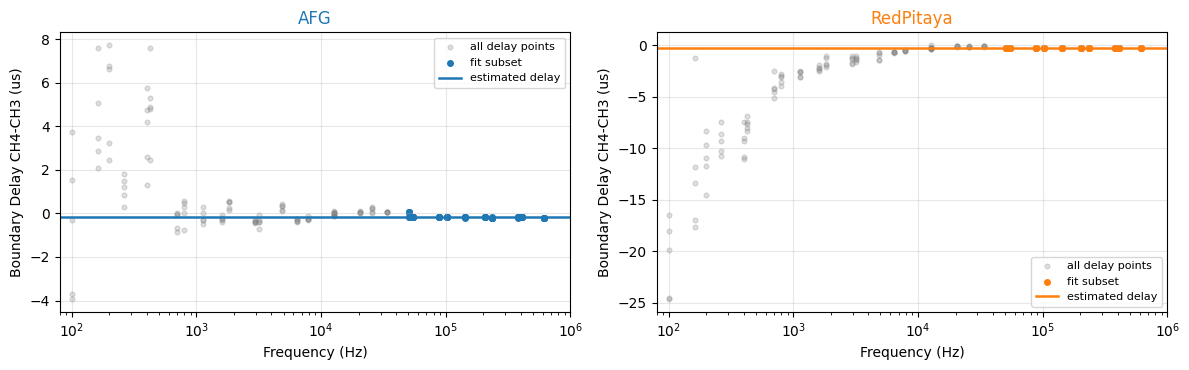

In [13]:
# Stage 2: Delay Estimation + Diagnostics
fig, axes = plt.subplots(1, len(dataset_data), figsize=(6 * len(dataset_data), 3.8), squeeze=False)
for col, (name, data) in enumerate(dataset_data.items()):
    raw = data["raw_points"]
    est_delay_s, delay_samples = estimate_constant_boundary_delay(
        raw,
        min_freq_hz=boundary_delay_min_freq_hz,
        weight_power=boundary_delay_weight_power,
    )
    applied_delay_s = est_delay_s if apply_boundary_delay else 0.0
    data["estimated_delay_s"] = est_delay_s
    data["applied_delay_s"] = applied_delay_s
    data["delay_samples"] = delay_samples

    print(
        f"{name}: estimated delay (CH4-CH3) = {est_delay_s*1e6:+.3f} us, "
        f"applied = {applied_delay_s*1e6:+.3f} us, samples = {len(delay_samples)}"
    )

    ax = axes[0, col]
    ax.scatter(raw["freq_hz"], raw["boundary_delay_s"] * 1e6, s=12, alpha=0.25, color="0.5", label="all delay points")
    ax.scatter(delay_samples["freq_hz"], delay_samples["boundary_delay_s"] * 1e6, s=16, color=data["color"], label="fit subset")
    ax.axhline(est_delay_s * 1e6, color=data["color"], linewidth=1.8, label="estimated delay")
    ax.set_xscale("log")
    ax.set_xlim(max(1.0, raw["freq_hz"].min() * 0.8), max_work_hz)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Boundary Delay CH4-CH3 (us)")
    ax.set_title(name, color=data["color"])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Section 5: Stage 3 - Inversion Run
Runs inversion using the configured transfer model and optional time-shift compensation.
Outputs `results` with per-dataset RMS and delay metadata.

In [14]:
# Stage 3: Inversion with Time-Shift Compensation
desired = np.loadtxt("../waveforms/shake_func.csv", delimiter=",")
duration_s = 50e-6
t = np.arange(desired.size) * (duration_s / desired.size)

desired = np.zeros_like(t)
for n in range(1, 10):
    desired += (1 / 11) * np.sin(
        2 * np.pi * np.random.random() * 250e3 * t + np.random.random() * 2 * np.pi
    )
desired *= (1 - np.cos(2 * np.pi * t / duration_s)) / 2

results = {}
for name, data in dataset_data.items():
    transfer = data["transfer"]
    applied_delay_s = data["applied_delay_s"]

    inv = invert_transfer(
        t,
        desired,
        transfer,
        regularization=regularization,
        max_boost_db=max_boost_db,
        phase_sign=phase_sign,
        outside_band_mode=outside_band_mode,
        max_work_hz=max_work_hz,
        system_delay_s=applied_delay_s,
        apply_time_shift_compensation=apply_time_shift_compensation,
    )
    rms_err = float(np.sqrt(np.mean((inv["predicted_output"] - desired) ** 2)))

    results[name] = {
        **data,
        **inv,
        "rms_error": rms_err,
    }
    print(
        f"{name}: RMS={rms_err:.5f} V, "
        f"delay={data['estimated_delay_s']*1e9:+.1f} ns, "
        f"corr_max={inv['correction_max_hz']:.1f} Hz"
    )

AFG: RMS=0.00082 V, delay=-185.3 ns, corr_max=615848.2 Hz
RedPitaya: RMS=0.00099 V, delay=-287.3 ns, corr_max=615848.2 Hz


## Section 6: Stage 4A - Calibration Diagnostics
Per-dataset calibration plots (gain and phase) with correction-band markers.

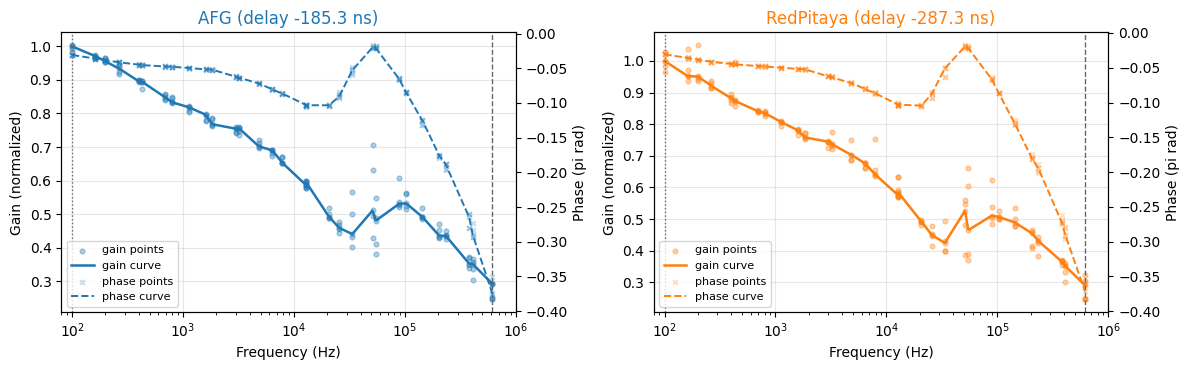

In [15]:
# Stage 4A: Calibration Diagnostics (Separate per Dataset)
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 3.8), squeeze=False)
global_cal_min = min(res["calibration_min_hz"] for res in results.values())
for col, (name, res) in enumerate(results.items()):
    raw = res["raw_points"]
    transfer = res["transfer"]
    color = res["color"]
    cal_min = res["calibration_min_hz"]
    cal_max = res["calibration_max_hz"]
    corr_max = res["correction_max_hz"]

    line_freq = np.logspace(np.log10(transfer["freq_hz"].min()), np.log10(transfer["freq_hz"].max()), 400)
    line_gain = _interp_log_frequency(line_freq, transfer["freq_hz"].to_numpy(float), transfer["gain"].to_numpy(float))
    line_phase = _interp_log_frequency(line_freq, transfer["freq_hz"].to_numpy(float), transfer["phase_pi"].to_numpy(float))

    ax = axes[0, col]
    ax.scatter(raw["freq_hz"], raw["gain"], s=12, alpha=0.35, color=color, label="gain points")
    ax.plot(line_freq, line_gain, color=color, linewidth=1.8, label="gain curve")
    ax.set_xscale("log")
    ax.set_xlim(max(1.0, global_cal_min * 0.8), max_work_hz)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Gain (normalized)")
    ax.set_title(f"{name} (delay {res['estimated_delay_s']*1e9:+.1f} ns)", color=color)
    ax.grid(alpha=0.3)

    axb = ax.twinx()
    axb.scatter(raw["freq_hz"], raw["phase_pi"], s=12, alpha=0.25, color=color, marker="x", label="phase points")
    axb.plot(line_freq, line_phase, color=color, linestyle="--", linewidth=1.4, label="phase curve")
    axb.set_ylabel("Phase (pi rad)")

    ax.axvline(cal_min, color="0.4", linestyle=":", linewidth=1.0)
    ax.axvline(corr_max, color="0.4", linestyle="--", linewidth=1.0)
    if cal_max > corr_max:
        ax.axvline(cal_max, color="0.6", linestyle=":", linewidth=1.0)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = axb.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

## Section 7: Stage 4B - Time-Domain Comparison
Full-width comparison of desired, drive, and predicted output waveforms across datasets.

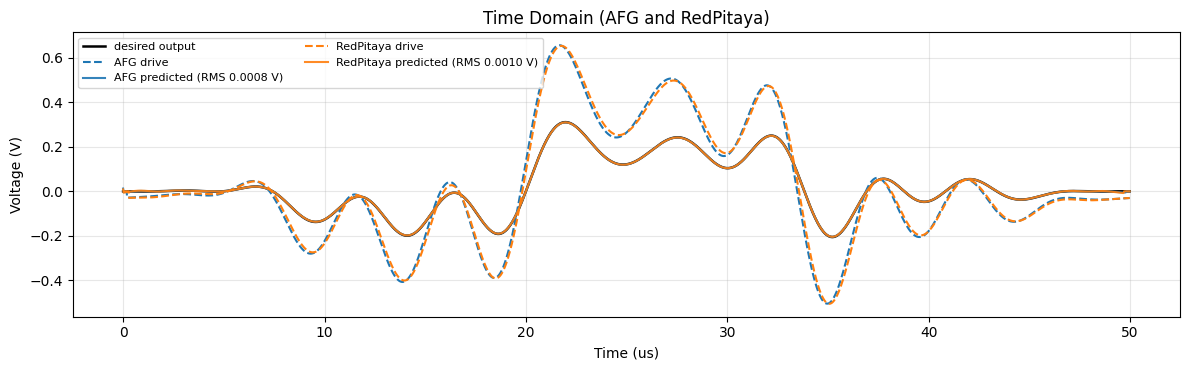

In [16]:
# Stage 4B: Time-Domain Comparison (Full Width)
fig, ax = plt.subplots(figsize=(12, 3.8))
view = t <= min(1.5e-3, t[-1])
ax.plot(t[view] * 1e6, desired[view], color="black", linewidth=1.8, label="desired output")
for name, res in results.items():
    color = res["color"]
    ax.plot(t[view] * 1e6, res["drive"][view], "--", color=color, label=f"{name} drive")
    ax.plot(t[view] * 1e6, res["predicted_output"][view], color=color, alpha=0.9, label=f"{name} predicted (RMS {res['rms_error']:.4f} V)")
ax.set_title("Time Domain (AFG and RedPitaya)")
ax.set_xlabel("Time (us)")
ax.set_ylabel("Voltage (V)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Section 8: Stage 4C - Spectral Comparison
Full-width magnitude spectra for desired vs drive, limited to working frequency range.

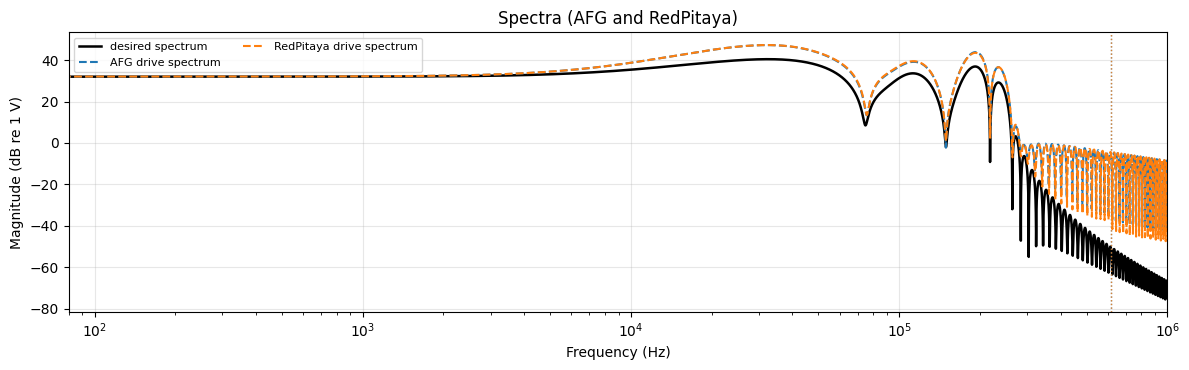

In [17]:
# Stage 4C: Spectra Comparison (Full Width)
eps = 1e-12
n_fft_plot = int(2 ** np.ceil(np.log2(max(desired.size, desired.size * plot_pad_factor))))
fft_freq_plot = np.fft.rfftfreq(n_fft_plot, d=t[1] - t[0])
desired_fft = np.fft.rfft(desired, n=n_fft_plot)
spec_mask = (fft_freq_plot > 0) & (fft_freq_plot <= max_work_hz)

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(fft_freq_plot[spec_mask], 20 * np.log10(np.maximum(np.abs(desired_fft[spec_mask]), eps)), color="black", linewidth=1.8, label="desired spectrum")
for name, res in results.items():
    color = res["color"]
    drive_fft = np.fft.rfft(res["drive"], n=n_fft_plot)
    ax.plot(fft_freq_plot[spec_mask], 20 * np.log10(np.maximum(np.abs(drive_fft[spec_mask]), eps)), "--", color=color, label=f"{name} drive spectrum")
    ax.axvline(res["correction_max_hz"], color=color, linestyle=":", linewidth=1.0, alpha=0.8)
ax.set_title("Spectra (AFG and RedPitaya)")
ax.set_xscale("log")
ax.set_xlim(max(1.0, min(res['calibration_min_hz'] for res in results.values()) * 0.8), max_work_hz)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB re 1 V)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Section 9: Stage 4D - Inverse Transfer Diagnostics
Per-dataset plots of `|H_inv|` and `angle(H_inv)` with calibration/correction markers.

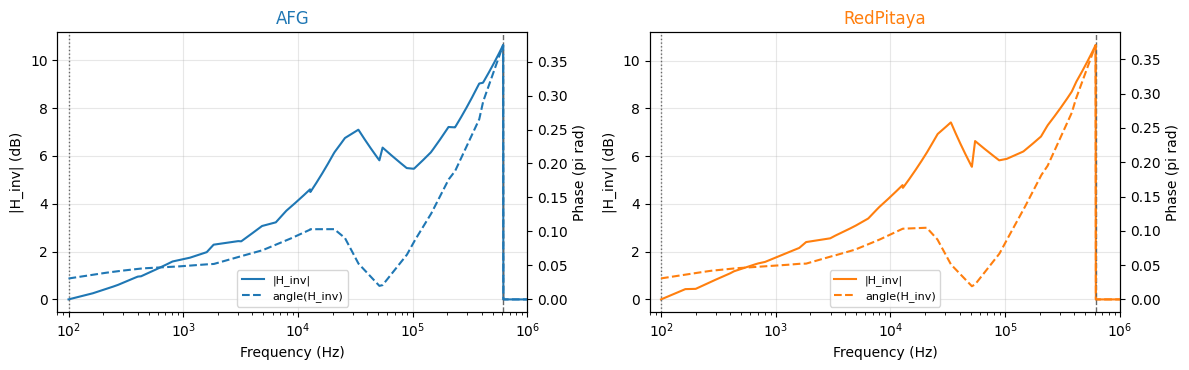

In [18]:
# Stage 4D: H_inv Diagnostics (Separate per Dataset)
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 3.8), squeeze=False)
global_cal_min = min(res["calibration_min_hz"] for res in results.values())
nyquist_hz = 0.5 / (t[1] - t[0])
for col, (name, res) in enumerate(results.items()):
    transfer = res["transfer"]
    color = res["color"]
    cal_min = res["calibration_min_hz"]
    cal_max = res["calibration_max_hz"]
    corr_max = res["correction_max_hz"]
    h_plot_max_hz = min(nyquist_hz, max_work_hz)
    h_plot_min_hz = max(1.0, cal_min)
    h_plot_freq = np.logspace(np.log10(h_plot_min_hz), np.log10(h_plot_max_hz), 2000)
    _, h_inv_plot, _, _, _ = inverse_response_on_frequency_grid(
        h_plot_freq,
        transfer,
        regularization=regularization,
        max_boost_db=max_boost_db,
        phase_sign=phase_sign,
        outside_band_mode=outside_band_mode,
        max_work_hz=max_work_hz,
    )
    h_inv_phase_pi = np.unwrap(np.angle(h_inv_plot)) / np.pi

    ax = axes[0, col]
    ax.plot(h_plot_freq, 20 * np.log10(np.maximum(np.abs(h_inv_plot), 1e-12)), color=color, label="|H_inv|")
    ax.set_xscale("log")
    ax.set_xlim(max(1.0, global_cal_min * 0.8), max_work_hz)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("|H_inv| (dB)")
    ax.set_title(name, color=color)
    ax.grid(alpha=0.3)
    axb = ax.twinx()
    axb.plot(h_plot_freq, h_inv_phase_pi, color=color, linestyle="--", label="angle(H_inv)")
    axb.set_ylabel("Phase (pi rad)")
    ax.axvline(cal_min, color="0.4", linestyle=":", linewidth=1.0)
    ax.axvline(corr_max, color="0.4", linestyle="--", linewidth=1.0)
    if cal_max > corr_max:
        ax.axvline(cal_max, color="0.6", linestyle=":", linewidth=1.0)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = axb.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best", fontsize=8)

plt.tight_layout()
plt.show()